In [2]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

repo_root = Path.cwd().parent
sys.path.append(str(repo_root))

import src.utils.config as config
import src.utils.pdata_io as pdio

data_root, pdata_root, cc_data = pdio.load_project_context()

print(data_root)
print(pdata_root)
print("Number of animals:", len(cc_data))

/home/nmldata2/ccaw/Python
[LOADED] Project context: /mnt/pdata/Classical_Conditioning/_cache/project_context.pkl
/mnt/data/Classical_Conditioning
/mnt/pdata/Classical_Conditioning
Number of animals: 5


In [3]:
import proc.process_behavior_signals as pbs

pbs.process_cc_data(
    cc_data,
    # animals={"NML_04"},
    # phase="tone_air_training", # "habituation", "air_training", "tone_air_training"
    # dates={"2026_01_13"},
    overwrite=True,
)

ModuleNotFoundError: No module named 'proc'

Let's visualize the signals and perform quality control 

In [8]:
animal = "NML_04"
date = "2026_01_04"
h5_file = pdio.behavior_h5_path(animal, date)
print(h5_file)

# see which keys are stored in the h5 file.
keys = pdio.list_behavior_h5_keys(animal, date)
print(keys)


animal = "NML_05"
date = "2026_01_04"
# Load full behavior file
b = pdio.load_behavior_h5(animal, date)
b.keys()


# Load selected keys (variable) from behavior file.
speed_path_cm = pdio.load_behavior_h5(
    animal,
    date,
    keys="speed_path_cms"
)

speed_path_cm


# from vis.plots import quick_plot_from_h5 as quick_plot

# quick_plot(cc_data, "NML_05", "2026_01_04")


/mnt/pdata/Classical_Conditioning/NML_04/2026_01_04/behavior/behavior_v1.h5
['Air_f', 'Air_r', 'air_bin', 'air_raw', 'bias', 'countsPerRev', 'dist_net_cm', 'dist_path_cm', 'encoderCount', 'fs', 'number_of_samples', 'si', 'speed_net_cms', 'speed_path_cms', 'speed_window_ms', 't', 'tm', 'trial_forward_cm']


{'speed_path_cms': array([1.00530965, 1.00530965, 1.00530965, ..., 0.        , 0.        ,
        0.        ])}

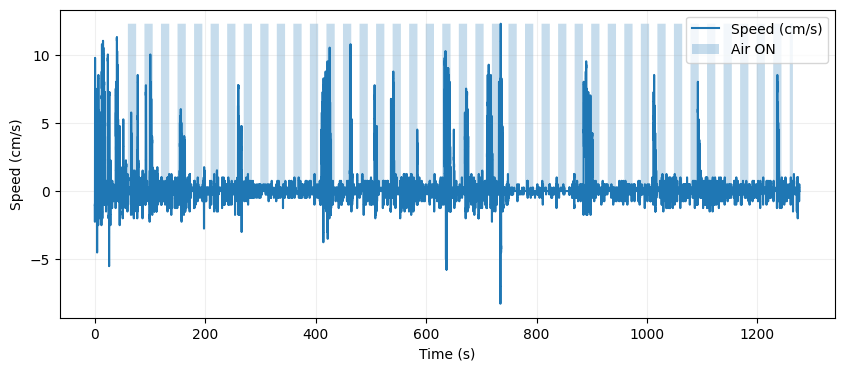

In [13]:
import numpy as np
import matplotlib.pyplot as plt

keys = [
        "t",
        "speed_net_cms",
        "air_bin",
    ]

b = pdio.load_behavior_h5(
        animal,
        date,
        keys=keys
    )

t = b["t"]
speed = b["speed_net_cms"]
air = b["air_bin"].astype(float)

fig, ax = plt.subplots(figsize=(10, 4))

 # -----------------------------
# Plot speed
# -----------------------------
ax.plot(t, speed, linewidth=1.5, label="Speed (cm/s)")

# -----------------------------
# Air shading
# -----------------------------
ymax = np.nanmax(speed) if np.nanmax(speed) > 0 else 1

ax.fill_between(
    t,
    0,
    air * ymax,
    alpha=0.25,
    label="Air ON"
)

# -----------------------------
# Labels
# -----------------------------
ax.set_xlabel("Time (s)")
ax.set_ylabel("Speed (cm/s)")

ax.legend()
ax.grid(alpha=0.2)



In [1]:

from vis.plots import quick_plot_speed_air


keys = ["t", "fs", "speed_net_cms", "air_bin"]

b = pdio.load_behavior_h5(
    animal,
    date,
    keys=keys
)

fig, ax = quick_plot_speed_air(
    b,
    speed_key="speed_net_cms",
    plot_fs=100,
    tlim=(1200,t[-1]),
    title=f"{animal} {date}"
)

ModuleNotFoundError: No module named 'vis'

In the above mentioned graph the last trial was interrupted and the switch was turned off for the fake air-stimulus during habituation. After interruption, the Matlab DAQ was also turned off.

So we are going to check the total times of all recordings.